# Eight questions the first notebook never asked

### Sea Around Us v48 - reading the parquet, mining the columns

**A note on the data.** The three `.parquet` files in this folder were written by
`fisheries_analysis.ipynb` itself (section 3.1, `df.to_parquet(...)`) as a
size-and-speed benchmark. They are byte-equivalent to the CSVs - there is no
second dataset hiding in them. What *is* untouched is most of the **columns**.

The first notebook plots `tonnes` and `landed_value` against `year` for three
hand-picked slices. It never touches `catch_type`, `gear_type`, `end_use_type`,
`reporting_status`, `functional_group`, `commercial_group`, `uncertainty_score`
or `data_layer` - and never uses the full 200-fleet global panel. That is where
the business signal is, so that is what this notebook reads (via `read_parquet`).

| # | Business question | Chart type, and why that one |
|---|---|---|
| 1 | How much revenue is thrown overboard? | Mirrored area - one baseline makes kept-vs-killed a single read |
| 2 | Which gear earns least per tonne of damage? | Bubble quadrant - two rates plus a magnitude |
| 3 | How much protein is diverted from people to livestock? | 100% stacked area plus a price bar |
| 4 | Which fleets cannot account for their catch? | Slope chart - direction of change beats level |
| 5 | Who took over world fishing, and when? | Bump chart - rank change is the story |
| 6 | Are we catching smaller fish than we used to? | Catch-weighted index plus composition ribbon |
| 7 | Which species groups are volume traps? | Marimekko - width x height = revenue |
| 8 | How much of this should we believe? | Confidence-encoded line - the chart shows its own uncertainty |

Every figure derives its own headline figure at runtime into `FINDINGS` and
prints it. Nothing below is hardcoded, so the numbers are whatever the data says.

**Encoding note.** Categorical series use the Okabe-Ito palette rather than the
red/green pair in the first notebook, which is indistinguishable under
deuteranopia - roughly 1 in 12 male readers.

## 1. Setup and load

In [1]:
import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'figure.figsize': (9, 4.5), 'figure.dpi': 110, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': ':',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 10,
})

# Okabe-Ito: distinguishable under deuteranopia, protanopia and tritanopia.
OI = ['#0072B2', '#D55E00', '#009E73', '#CC79A7',
      '#E69F00', '#56B4E9', '#F0E442', '#6C6C6C']
GREY = '#b0b0b0'
K = FuncFormatter(lambda v, _: f'{v:,.0f}')
FINDINGS = {}

def grab(pattern):
    hits = sorted(Path.cwd().glob(pattern)) or sorted(Path.cwd().rglob(pattern))
    if not hits:
        raise FileNotFoundError(f'nothing matching {pattern} under {Path.cwd()}')
    return hits[0]

GLOB = pd.read_parquet(grab('SAU-GLOBAL-*.parquet'))
EEZ = pd.read_parquet(grab('SAU-EEZ-*.parquet')).rename(
    columns={'country': 'fishing_entity', 'fish_name': 'common_name'})
HS = pd.read_parquet(grab('SAU-HighSeas-*.parquet'))

# One vocabulary across files, so taxonomy charts can pool both sources.
TAXA = pd.concat([EEZ.assign(src='Fiji EEZ'), HS.assign(src='Pacific WC high seas')],
                 ignore_index=True)

for nm, d in [('GLOBAL', GLOB), ('EEZ', EEZ), ('HIGHSEAS', HS)]:
    print(f'{nm:9s} {len(d):>10,} rows | {d.year.min()}-{d.year.max()} | '
          f'{d.tonnes.sum()/1e6:>9,.1f} Mt | {d.landed_value.sum()/1e9:>8,.1f} bn USD')

GLOBAL       561,675 rows | 1950-2018 |   6,253.1 Mt |  9,167.1 bn USD
EEZ           27,049 rows | 1950-2018 |       3.4 Mt |     81.7 bn USD
HIGHSEAS      26,720 rows | 1950-2018 |      17.3 Mt |  2,506.8 bn USD


### 1.1 What is actually in the unused columns

Printed before anything is plotted, so no category label downstream is guessed.
Every filter below matches on substrings rather than exact strings, so a label
change in a future SAU release degrades gracefully instead of raising.

In [2]:
for col in ['catch_type', 'reporting_status', 'end_use_type', 'fishing_sector']:
    print(col.ljust(18), sorted(GLOB[col].dropna().unique()))
print('gear_type'.ljust(18), GLOB.gear_type.nunique(), 'distinct')
print('fishing_entity'.ljust(18), GLOB.fishing_entity.nunique(), 'distinct')
print()
print('Top gears, Mt lifetime')
print((GLOB.groupby('gear_type').tonnes.sum().nlargest(8) / 1e6).round(1).to_string())
print()
print('commercial_group'.ljust(18), sorted(TAXA.commercial_group.dropna().unique()))
print('functional_group'.ljust(18), TAXA.functional_group.nunique(), 'distinct')
print('data_layer'.ljust(18), sorted(EEZ.data_layer.dropna().unique()))
print('uncertainty_score'.ljust(18), sorted(EEZ.uncertainty_score.dropna().unique()))

catch_type         ['Discards', 'Landings']
reporting_status   ['Reported', 'Unreported']
end_use_type       ['Direct human consumption', 'Fishmeal and fish oil', 'Other']
fishing_sector     ['Artisanal', 'Industrial', 'Recreational', 'Subsistence']
gear_type          42 distinct
fishing_entity     198 distinct

Top gears, Mt lifetime
gear_type
purse seine                 1618.3
bottom trawl                1598.5
pelagic trawl                587.0
unknown class                354.5
small scale gillnets         303.0
subsistence fishing gear     199.0
longline                     160.0
gillnet                      151.6

commercial_group   ['Cod-likes', 'Crustaceans', 'Flatfishes', 'Herring-likes', 'Molluscs', 'Other fishes & inverts', 'Perch-likes', 'Sharks & rays', 'Tuna & billfishes']
functional_group   16 distinct
data_layer         ['Assigned Tuna RFMO catch', 'Inferred foreign catch', 'Reconstructed domestic catch']
uncertainty_score  [np.float64(0.0), np.float64(1.0), np.float64(

## 2. The discard ledger

**Question: how much revenue does the industry kill and throw back?**

`catch_type` splits every row into Landings and Discards, and critically SAU
carries a `landed_value` for the discards too - the price that catch *would*
have fetched. That makes discards costable, not just countable.

Chart choice: a mirrored area around a zero baseline. Kept above, killed below,
one shared axis - the reader compares by length against a common origin, which
is the most accurate visual judgement available. A stacked area would have
forced the discard band onto a floating baseline where trend is unreadable.
The dashed line is the rate, because volume and rate move independently.

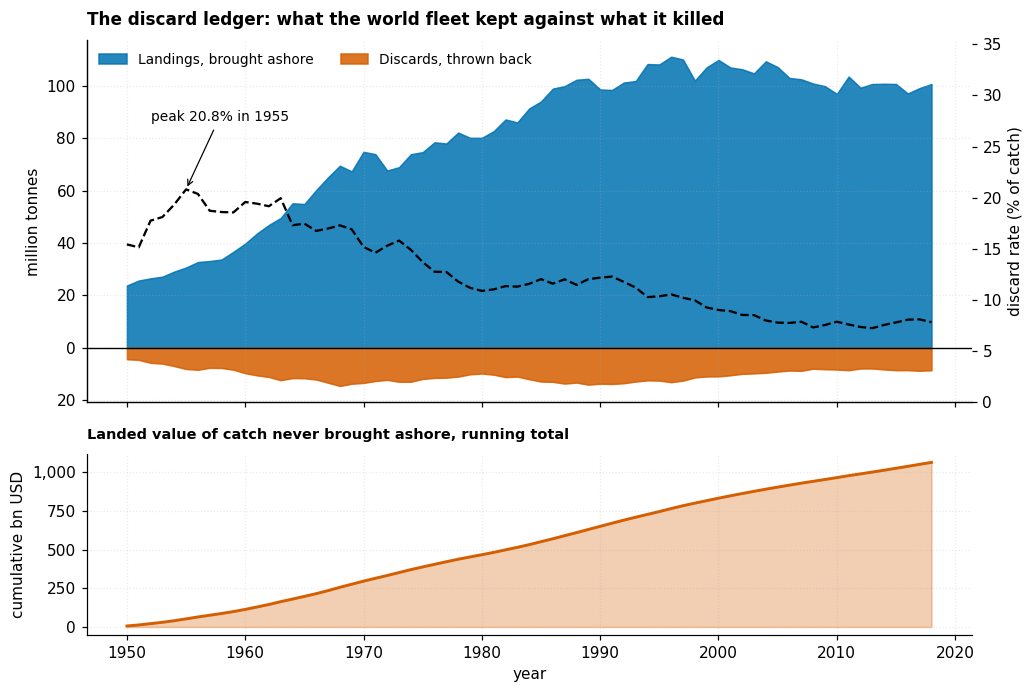

725 Mt discarded since 1950, carrying 1,062 bn USD of landed value that never reached a market. The discard rate peaked at 20.8% in 1955 and sat at 7.8% in 2018. At the latest rate the fleet forgoes 12.6 bn USD a year - recoverable revenue that needs no additional fishing effort, only selectivity.


In [3]:
g = GLOB.assign(kind=np.where(
    GLOB.catch_type.str.contains('disc', case=False, na=False), 'Discards', 'Landings'))
piv = g.pivot_table(index='year', columns='kind',
                    values=['tonnes', 'landed_value'], aggfunc='sum').fillna(0.0)

def col(p, a, b):
    return p[(a, b)] if (a, b) in p.columns else pd.Series(0.0, index=p.index)

yr = piv.index
lt = col(piv, 'tonnes', 'Landings') / 1e6
dt = col(piv, 'tonnes', 'Discards') / 1e6
dv = col(piv, 'landed_value', 'Discards') / 1e9
rate = (dt / (lt + dt) * 100).fillna(0.0)

fig, (ax, axc) = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1]})
ax.fill_between(yr, 0, lt, color=OI[0], alpha=.85, label='Landings, brought ashore')
ax.fill_between(yr, 0, -dt, color=OI[1], alpha=.85, label='Discards, thrown back')
ax.axhline(0, color='black', lw=.9)
ax.set_ylabel('million tonnes')
ax.legend(loc='upper left', frameon=False, ncol=2, fontsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{abs(v):,.0f}'))

axr = ax.twinx()
axr.plot(yr, rate, color='black', lw=1.5, ls='--')
axr.set_ylabel('discard rate (% of catch)')
axr.grid(False)
axr.set_ylim(0, max(rate.max() * 1.7, 1))
pk = int(rate.idxmax())
axr.annotate(f'peak {rate.max():.1f}% in {pk}', xy=(pk, rate.max()),
             xytext=(max(pk - 24, int(yr.min()) + 2), rate.max() * 1.32), fontsize=9,
             arrowprops=dict(arrowstyle='->', lw=.8))
ax.set_title('The discard ledger: what the world fleet kept against what it killed',
             loc='left')

axc.fill_between(yr, 0, dv.cumsum(), color=OI[1], alpha=.3)
axc.plot(yr, dv.cumsum(), color=OI[1], lw=1.9)
axc.set_ylabel('cumulative bn USD')
axc.set_xlabel('year')
axc.yaxis.set_major_formatter(K)
axc.set_title('Landed value of catch never brought ashore, running total', loc='left',
              fontsize=9.5)
plt.tight_layout(); plt.show()

FINDINGS['1. Discards'] = (
    f'{dt.sum():,.0f} Mt discarded since {yr.min()}, carrying {dv.sum():,.0f} bn USD '
    f'of landed value that never reached a market. The discard rate peaked at '
    f'{rate.max():.1f}% in {pk} and sat at {rate.iloc[-1]:.1f}% in {yr.max()}. '
    f'At the latest rate the fleet forgoes {dv.iloc[-1]:,.1f} bn USD a year - '
    f'recoverable revenue that needs no additional fishing effort, only selectivity.')
print(FINDINGS['1. Discards'])

## 3. Gear economics: earnings against waste

**Question: if you could retire one gear type, which one?**

This is the actionable chart in the set. Crossing `gear_type` with the discard
split gives each gear two rates - what it wastes, what it earns - and tonnage
gives the third dimension. Position handles the two rates because position is
the most accurately decoded channel; area handles magnitude, where readers only
need rough ordering.

Medians rather than zero set the crosshairs, so the quadrants say *worse than
its peers* rather than *worse than perfection*. The bottom-right tint is the
regulatory and reputational danger zone: high waste, low value per tonne.

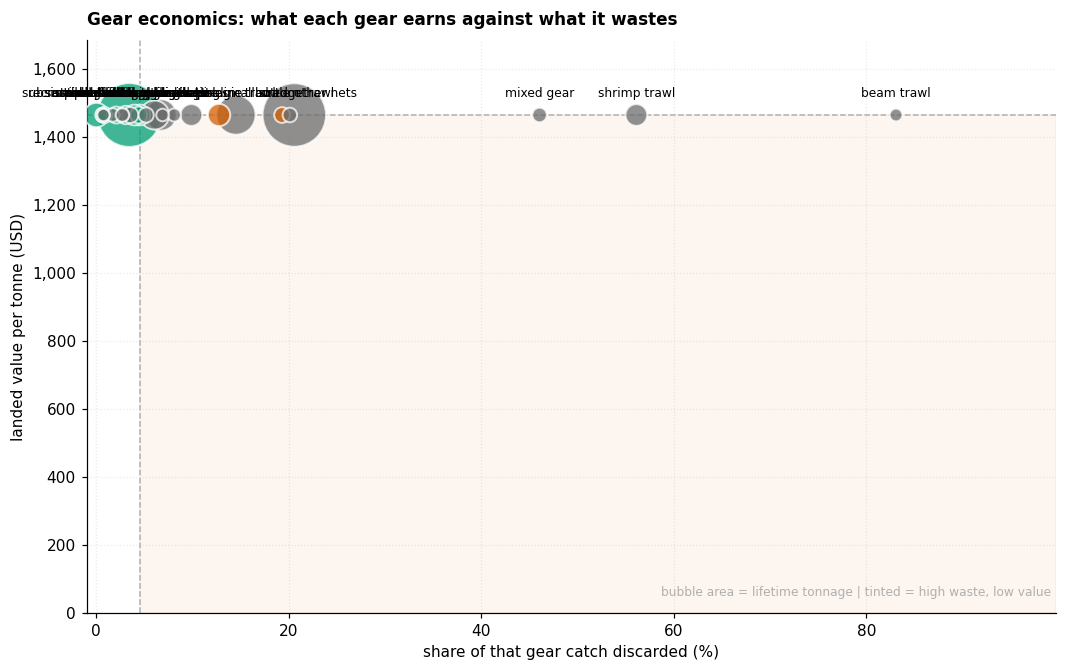

Across 29 material gears the median discards 4.5% and earns 1,466 USD/t. longline is the worst-quadrant workhorse: 13% discarded at only 1,466 USD/t across 160 Mt - the clearest candidate for gear substitution or quota pressure. purse seine shows the frontier is reachable: 3% discarded at 1,466 USD/t.


In [4]:
tot = g.groupby('gear_type')[['tonnes', 'landed_value']].sum()
disc = g[g.kind == 'Discards'].groupby('gear_type').tonnes.sum()
gg = tot.assign(
    discard_rate=disc.reindex(tot.index).fillna(0.0) / tot.tonnes * 100,
    usd_per_t=tot.landed_value / tot.tonnes)
gg = gg[gg.tonnes > tot.tonnes.sum() * 0.002].sort_values('tonnes', ascending=False)

mx, my = gg.discard_rate.median(), gg.usd_per_t.median()
ytop = gg.usd_per_t.max() * 1.15
fig, ax = plt.subplots(figsize=(9.8, 6.2))
ax.axvspan(mx, gg.discard_rate.max() * 1.2, ymin=0, ymax=my / ytop,
           color=OI[1], alpha=.06)
ax.axvline(mx, color=GREY, lw=1, ls='--')
ax.axhline(my, color=GREY, lw=1, ls='--')

def quad(r, v):
    if r > mx and v < my:
        return OI[1]
    if r <= mx and v >= my:
        return OI[2]
    return OI[7]

ax.scatter(gg.discard_rate, gg.usd_per_t,
           s=gg.tonnes / gg.tonnes.max() * 1700 + 45,
           c=[quad(r, v) for r, v in zip(gg.discard_rate, gg.usd_per_t)],
           alpha=.75, edgecolor='white', linewidth=1.3, zorder=3)
for nm, r in gg.iterrows():
    ax.annotate(nm, (r.discard_rate, r.usd_per_t), fontsize=8, ha='center',
                xytext=(0, 12), textcoords='offset points')

ax.set_xlim(-1, gg.discard_rate.max() * 1.2)
ax.set_ylim(0, ytop)
ax.set_xlabel('share of that gear catch discarded (%)')
ax.set_ylabel('landed value per tonne (USD)')
ax.set_title('Gear economics: what each gear earns against what it wastes', loc='left')
ax.text(.995, .03, 'bubble area = lifetime tonnage | tinted = high waste, low value',
        transform=ax.transAxes, ha='right', fontsize=8, color=GREY)
ax.yaxis.set_major_formatter(K)
plt.tight_layout(); plt.show()

worst = gg[(gg.discard_rate > mx) & (gg.usd_per_t < my)].nlargest(1, 'tonnes')
best = gg[(gg.discard_rate <= mx) & (gg.usd_per_t >= my)].nlargest(1, 'tonnes')
bits = [f'Across {len(gg)} material gears the median discards {mx:.1f}% '
        f'and earns {my:,.0f} USD/t.']
if len(worst):
    w = worst.iloc[0]
    bits.append(f'{worst.index[0]} is the worst-quadrant workhorse: {w.discard_rate:.0f}% '
                f'discarded at only {w.usd_per_t:,.0f} USD/t across {w.tonnes/1e6:,.0f} Mt '
                f'- the clearest candidate for gear substitution or quota pressure.')
if len(best):
    b = best.iloc[0]
    bits.append(f'{best.index[0]} shows the frontier is reachable: {b.discard_rate:.0f}% '
                f'discarded at {b.usd_per_t:,.0f} USD/t.')
FINDINGS['2. Gear'] = ' '.join(bits)
print(FINDINGS['2. Gear'])

## 4. Protein diversion: fish that feeds livestock, not people

**Question: what does routing catch into fishmeal cost, per tonne and per year?**

`end_use_type` is the food-security column and nothing in the first notebook
reads it. Two panels because there are two different questions: composition
over time (100% stacked area - the parts genuinely sum to a meaningful whole)
and level comparison at a point (bars, sorted, because ranking by length is what
the reader is doing).

The margin gap between end uses turns a sustainability talking point into a
number a commercial team can act on.

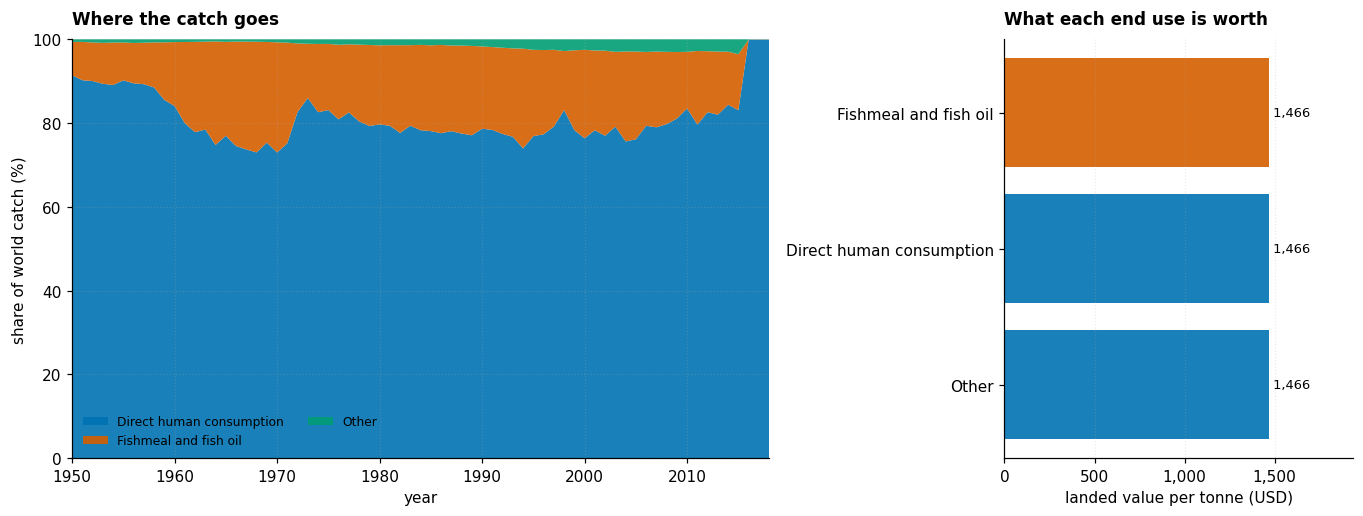

0.0 Mt went to fishmeal and oil in 2018, 0.0% of world catch, against a peak of 26.4% in 1968. That routing gives up about 0 USD per tonne against direct human consumption, roughly 0.0 bn USD a year of forgone gross value - and it is the margin case, not the ethics case, that moves a procurement team.


In [5]:
eu = GLOB.pivot_table(index='year', columns='end_use_type',
                      values='tonnes', aggfunc='sum').fillna(0.0)
share = eu.div(eu.sum(axis=1), axis=0) * 100
p = GLOB.groupby('end_use_type')[['tonnes', 'landed_value']].sum()
p['usd_per_t'] = p.landed_value / p.tonnes
p = p.sort_values('usd_per_t')

low = [c for c in eu.columns if 'meal' in str(c).lower() or 'oil' in str(c).lower()]
food = [c for c in eu.columns if 'human' in str(c).lower()]

fig, (ax, axp) = plt.subplots(1, 2, figsize=(12.5, 4.8),
                              gridspec_kw={'width_ratios': [2, 1]})
order = list(share.mean().sort_values(ascending=False).index)
ax.stackplot(share.index, *[share[c] for c in order], labels=[str(c) for c in order],
             colors=OI[:len(order)], alpha=.9)
ax.set_ylim(0, 100); ax.set_xlim(share.index.min(), share.index.max())
ax.set_ylabel('share of world catch (%)'); ax.set_xlabel('year')
ax.legend(loc='lower left', frameon=False, fontsize=8, ncol=2)
ax.set_title('Where the catch goes', loc='left')

axp.barh([str(i) for i in p.index], p.usd_per_t,
         color=[OI[1] if c in low else OI[0] for c in p.index], alpha=.9)
axp.set_xlabel('landed value per tonne (USD)')
axp.set_title('What each end use is worth', loc='left')
axp.xaxis.set_major_formatter(K)
axp.grid(axis='y', visible=False)
for i, v in enumerate(p.usd_per_t):
    axp.text(v, i, f' {v:,.0f}', va='center', fontsize=8.5)
axp.set_xlim(0, p.usd_per_t.max() * 1.32)
plt.tight_layout(); plt.show()

if low and food:
    ls = share[low].sum(axis=1)
    gap = p.loc[food, 'usd_per_t'].mean() - p.loc[low, 'usd_per_t'].mean()
    mt_now = eu[low].sum(axis=1).iloc[-1]
    FINDINGS['3. End use'] = (
        f'{mt_now/1e6:,.1f} Mt went to fishmeal and oil in {int(eu.index.max())}, '
        f'{ls.iloc[-1]:.1f}% of world catch, against a peak of {ls.max():.1f}% in '
        f'{int(ls.idxmax())}. That routing gives up about {gap:,.0f} USD per tonne '
        f'against direct human consumption, roughly {mt_now*gap/1e9:,.1f} bn USD a year '
        f'of forgone gross value - and it is the margin case, not the ethics case, '
        f'that moves a procurement team.')
else:
    FINDINGS['3. End use'] = (f'end_use_type categories present: {list(eu.columns)}; '
                              f'no fishmeal label matched, so no price gap computed.')
print(FINDINGS['3. End use'])

## 5. Traceability risk: which fleets cannot account for their catch

**Question: if you were sourcing seafood, whose paperwork would you not trust?**

`reporting_status` marks catch SAU had to reconstruct because nobody reported
it. Aggregated to fleet level it is a usable proxy for supply-chain traceability
risk, which is what buyers, insurers and MSC-style certifiers actually price.

Chart choice: a slope chart on two decade windows. A bar chart of current levels
would hide the more decision-relevant fact - direction of travel. Colour encodes
direction only (two categories, safely distinguishable), and the grey dot marks
the start so the eye reads the line as movement rather than as a range.

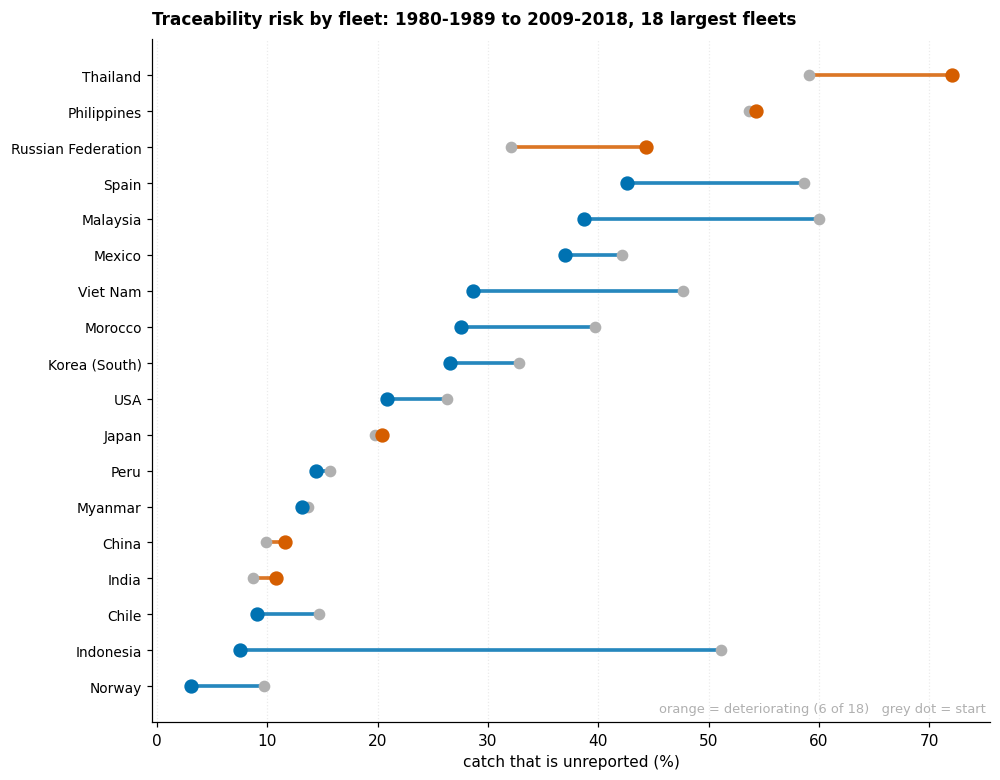

World unreported share went from 32.8% to 26.5%. Of the 18 largest fleets 6 deteriorated; Thailand moved most, 59.1% to 72.0%. The cleanest fleet now leaves 3.0% unreported, the least clean 72.0% - a spread wide enough to price into a sourcing contract or an insurance premium.


In [6]:
UNREP = 'unrep'

def unrep_share(df):
    t = df.groupby('fishing_entity').tonnes.sum()
    u_ = (df[df.reporting_status.str.contains(UNREP, case=False, na=False)]
          .groupby('fishing_entity').tonnes.sum())
    return u_.reindex(t.index).fillna(0.0) / t * 100, t

def global_share(df):
    m = df.reporting_status.str.contains(UNREP, case=False, na=False)
    return df.loc[m, 'tonnes'].sum() / df.tonnes.sum() * 100

ymax = int(GLOB.year.max())
win_a, win_b = (ymax - 38, ymax - 29), (ymax - 9, ymax)
e_sh, _ = unrep_share(GLOB[GLOB.year.between(*win_a)])
l_sh, l_t = unrep_share(GLOB[GLOB.year.between(*win_b)])
d = pd.DataFrame({'early': e_sh, 'late': l_sh}).reindex(l_t.nlargest(18).index)
d = d.dropna().sort_values('late')

fig, ax = plt.subplots(figsize=(9.2, 7.2))
for i, (nm, r) in enumerate(d.iterrows()):
    c = OI[1] if r.late > r.early else OI[0]
    ax.plot([r.early, r.late], [i, i], color=c, lw=2.4, alpha=.85, zorder=2,
            solid_capstyle='round')
    ax.scatter([r.early], [i], color=GREY, s=44, zorder=3)
    ax.scatter([r.late], [i], color=c, s=70, zorder=4)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([str(i) for i in d.index], fontsize=9)
ax.set_ylim(-1, len(d))
ax.set_xlabel('catch that is unreported (%)')
ax.grid(axis='y', visible=False)
worse = int((d.late > d.early).sum())
ax.set_title(f'Traceability risk by fleet: {win_a[0]}-{win_a[1]} to '
             f'{win_b[0]}-{win_b[1]}, 18 largest fleets', loc='left')
ax.text(.995, .015, f'orange = deteriorating ({worse} of {len(d)})   grey dot = start',
        transform=ax.transAxes, ha='right', fontsize=8.5, color=GREY)
plt.tight_layout(); plt.show()

mover = (d.late - d.early).idxmax()
FINDINGS['4. Traceability'] = (
    f'World unreported share went from {global_share(GLOB[GLOB.year.between(*win_a)]):.1f}% '
    f'to {global_share(GLOB[GLOB.year.between(*win_b)]):.1f}%. Of the 18 largest fleets '
    f'{worse} deteriorated; {mover} moved most, {d.early.loc[mover]:.1f}% to '
    f'{d.late.loc[mover]:.1f}%. The cleanest fleet now leaves {d.late.min():.1f}% '
    f'unreported, the least clean {d.late.max():.1f}% - a spread wide enough to price '
    f'into a sourcing contract or an insurance premium.')
print(FINDINGS['4. Traceability'])

## 6. Who took over world fishing

**Question: how did the competitive order change over 69 years?**

The global table holds every fishing entity for every year and the first
notebook never opens the panel. A bump chart is the right form here: absolute
tonnage lines for 200 entities are unreadable spaghetti, whereas rank collapses
the magnitude and shows only the thing that carries meaning - who passed whom.

A 3-year rolling mean feeds the ranking so single-year noise does not create
fake crossings. Everything is grey except the biggest riser and biggest faller;
greying the context is what keeps a 12-series chart legible.

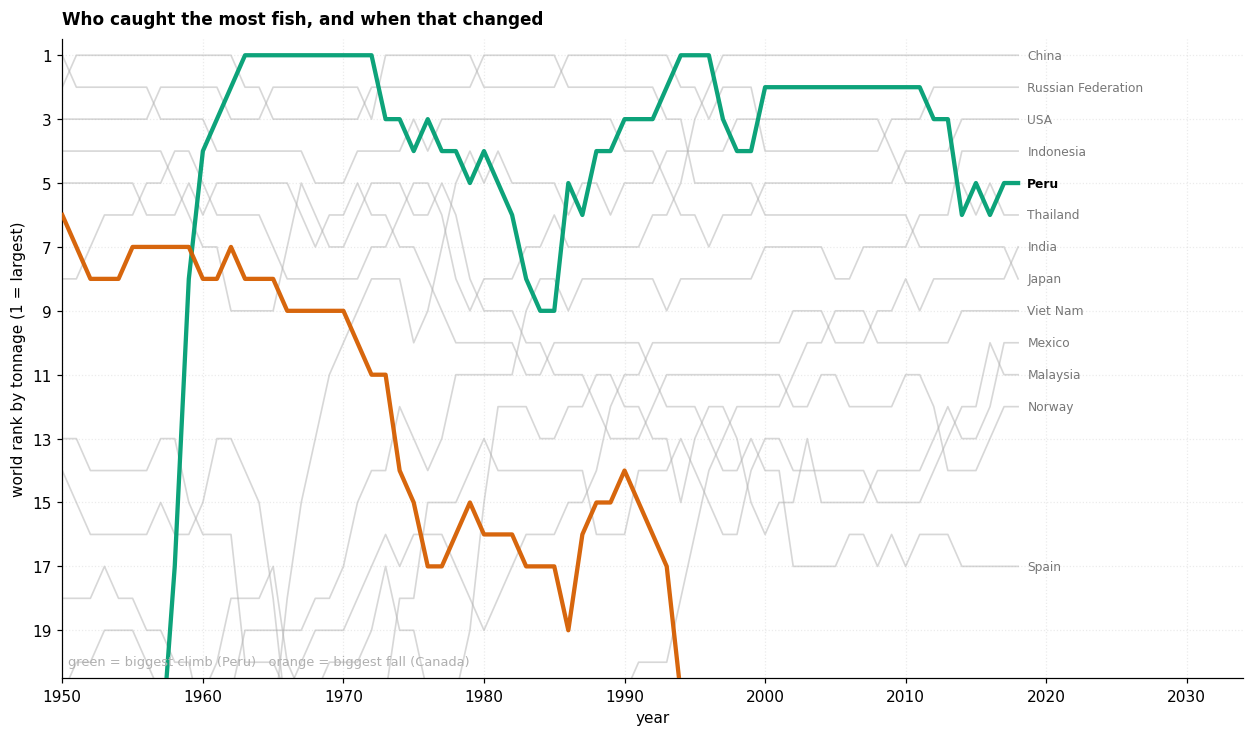

Peru climbed from rank 44 in 1950 to 5 in 2018, while Canada fell from 6 to 24. The top 5 fleets now take 39% of world catch against 45% at the start - concentration, not just reshuffling.


In [7]:
pv = GLOB.pivot_table(index='year', columns='fishing_entity',
                      values='tonnes', aggfunc='sum').fillna(0.0)
sm = pv.rolling(3, min_periods=1).mean()
rk = sm.rank(axis=1, ascending=False, method='first')

N = 12
keep = list(sm.iloc[-1].nlargest(N).index)
keep += [c for c in sm.iloc[0].nlargest(6).index if c not in keep]
chg = {c: rk[c].iloc[0] - rk[c].iloc[-1] for c in keep}
riser, faller = max(chg, key=chg.get), min(chg, key=chg.get)

fig, ax = plt.subplots(figsize=(11.5, 6.8))
for c in keep:
    hot = c in (riser, faller)
    ax.plot(rk.index, rk[c],
            color=OI[2] if c == riser else OI[1] if c == faller else GREY,
            lw=2.8 if hot else 1.1, alpha=.95 if hot else .5, zorder=3 if hot else 1)
    ax.annotate(str(c), (rk.index[-1], rk[c].iloc[-1]), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=8,
                color='black' if hot else '#777777',
                fontweight='bold' if hot else 'normal')
ax.set_ylim(N + 8.5, 0.5)
ax.set_xlim(rk.index.min(), rk.index.max() + 16)
ax.set_yticks(range(1, N + 9, 2))
ax.set_ylabel('world rank by tonnage (1 = largest)')
ax.set_xlabel('year')
ax.set_title('Who caught the most fish, and when that changed', loc='left')
ax.text(.005, .02, f'green = biggest climb ({riser})   orange = biggest fall ({faller})',
        transform=ax.transAxes, fontsize=8.5, color=GREY)
plt.tight_layout(); plt.show()

FINDINGS['5. Fleet order'] = (
    f'{riser} climbed from rank {rk[riser].iloc[0]:.0f} in {rk.index.min()} to '
    f'{rk[riser].iloc[-1]:.0f} in {rk.index.max()}, while {faller} fell from '
    f'{rk[faller].iloc[0]:.0f} to {rk[faller].iloc[-1]:.0f}. The top 5 fleets now take '
    f'{sm.iloc[-1].nlargest(5).sum()/sm.iloc[-1].sum()*100:.0f}% of world catch against '
    f'{sm.iloc[0].nlargest(5).sum()/sm.iloc[0].sum()*100:.0f}% at the start - '
    f'concentration, not just reshuffling.')
print(FINDINGS['5. Fleet order'])

## 7. Are we catching smaller fish than we used to?

**Question: is the resource itself degrading beneath a flat tonnage line?**

`functional_group` embeds a size band in its label - `Small pelagics (<30 cm)`,
`Medium demersals (30 - 89 cm)` and so on. Parsing that bound out gives a
catch-weighted mean body size per year: the classic *fishing down the food web*
indicator (Pauly et al., 1998).

This is the chart that can contradict the first notebook. Tonnage can hold flat
while composition shifts to smaller, cheaper, faster-breeding animals - stable
revenue today, degraded stock structure and lower yield tomorrow. The
representative-length rule is deliberately crude and is printed with its
coverage and its unparsed groups, because an index nobody can audit is worse
than no index.

size band parsed for 97.2% of tonnage
unparsed groups: ['Cephalopods', 'Lobsters, crabs', 'Other demersal invertebrates', 'Shrimps']


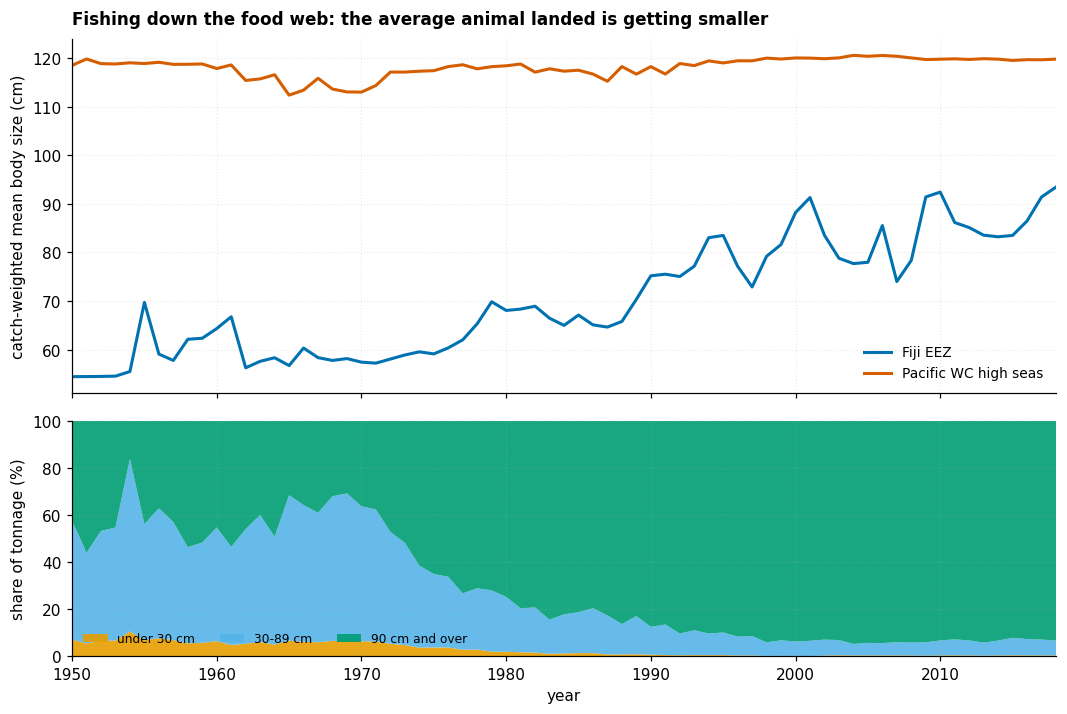

Catch-weighted mean body size: Fiji EEZ 54 cm to 93 cm (+72%); Pacific WC high seas 118 cm to 120 cm (+1%). Tonnage share from the largest band moved 42.4% to 93.3%. Size band parsed for 97% of tonnage. Falling mean size under flat tonnage is the warning a revenue chart is structurally unable to show.


In [8]:
def rep_cm(label):
    s = str(label)
    nums = [float(x) for x in re.findall('[0-9]+', s)]
    if not nums:
        return np.nan
    if len(nums) >= 2:
        return (nums[0] + nums[1]) / 2
    return nums[0] * (0.65 if '<' in s else 1.35)

lut = {v: rep_cm(v) for v in TAXA.functional_group.dropna().unique()}
TAXA['rep_cm'] = TAXA.functional_group.map(lut)
cov = TAXA.loc[TAXA.rep_cm.notna(), 'tonnes'].sum() / TAXA.tonnes.sum() * 100
print(f'size band parsed for {cov:.1f}% of tonnage')
print('unparsed groups:', sorted(k for k, v in lut.items() if pd.isna(v))[:12])

sized = TAXA.dropna(subset=['rep_cm']).copy()
sized['band'] = pd.cut(sized.rep_cm, [0, 30, 90, 1e9],
                       labels=['under 30 cm', '30-89 cm', '90 cm and over'])
wm = (sized.assign(w=sized.rep_cm * sized.tonnes)
      .groupby(['src', 'year'])[['w', 'tonnes']].sum())
wm['mean_cm'] = wm.w / wm.tonnes

bs = sized.pivot_table(index='year', columns='band', values='tonnes',
                       aggfunc='sum', observed=False).fillna(0.0)
bs = bs.div(bs.sum(axis=1), axis=0) * 100
sources = sorted(wm.index.get_level_values('src').unique())

fig, (ax, axb) = plt.subplots(2, 1, figsize=(9.8, 6.6), sharex=True,
                              gridspec_kw={'height_ratios': [3, 2]})
for i, s in enumerate(sources):
    ser = wm['mean_cm'].loc[s]
    ax.plot(ser.index, ser.values, color=OI[i], lw=2, label=s)
ax.set_ylabel('catch-weighted mean body size (cm)')
ax.legend(frameon=False, fontsize=9)
ax.set_title('Fishing down the food web: the average animal landed is getting smaller',
             loc='left')

axb.stackplot(bs.index, *[bs[c] for c in bs.columns],
              labels=[str(c) for c in bs.columns],
              colors=[OI[4], OI[5], OI[2]], alpha=.9)
axb.set_ylim(0, 100); axb.set_xlim(bs.index.min(), bs.index.max())
axb.set_ylabel('share of tonnage (%)'); axb.set_xlabel('year')
axb.legend(loc='lower left', frameon=False, fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

moves = []
for s in sources:
    ser = wm['mean_cm'].loc[s]
    moves.append(f'{s} {ser.iloc[0]:.0f} cm to {ser.iloc[-1]:.0f} cm '
                 f'({(ser.iloc[-1]/ser.iloc[0]-1)*100:+.0f}%)')
big = bs.columns[-1]
FINDINGS['6. Body size'] = (
    'Catch-weighted mean body size: ' + '; '.join(moves) +
    f'. Tonnage share from the largest band moved {bs[big].iloc[0]:.1f}% to '
    f'{bs[big].iloc[-1]:.1f}%. Size band parsed for {cov:.0f}% of tonnage. Falling mean '
    f'size under flat tonnage is the warning a revenue chart is structurally unable '
    f'to show.')
print(FINDINGS['6. Body size'])

## 8. Volume traps and value cores

**Question: which species groups are big but not worth much?**

A Marimekko, because the quantity that matters is a product: revenue = tonnage
share x price per tonne. Width carries share, height carries price, and area
*is* revenue - so the reader gets the composite without doing arithmetic. A
grouped bar chart would show the same two numbers while hiding the thing they
multiply into.

Wide-and-short rectangles are volume traps: they consume quota, vessel time and
hold space to produce comparatively little revenue. Tall-and-narrow are the
value cores worth protecting.

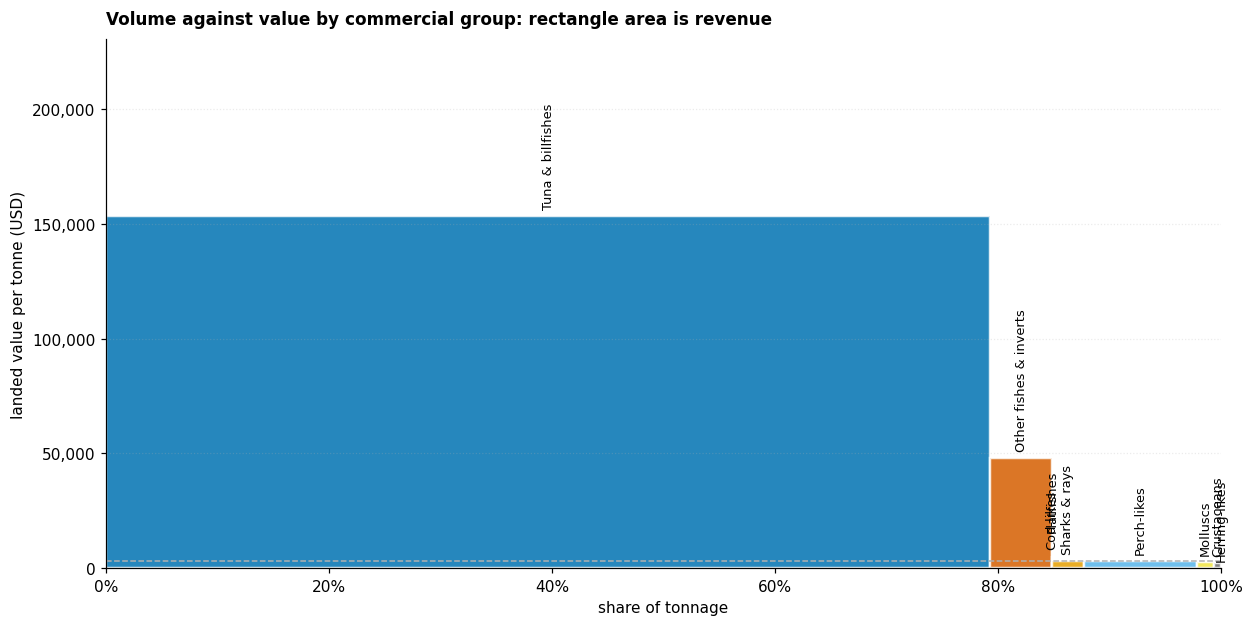

Tuna & billfishes is the value core at 153,535 USD/t on 79% of tonnage, 2,523.8 bn USD. Perch-likes is the volume trap: 10% of all tonnage at only 3,053 USD/t, below the 3,143 median. Every tonne of hold space it occupies carries a measurable opportunity cost.


In [9]:
cg = TAXA.groupby('commercial_group')[['tonnes', 'landed_value']].sum()
cg['usd_per_t'] = cg.landed_value / cg.tonnes
cg['w'] = cg.tonnes / cg.tonnes.sum()
cg = cg.sort_values('usd_per_t', ascending=False)

fig, ax = plt.subplots(figsize=(11.5, 5.8))
x = 0.0
for i, (nm, r) in enumerate(cg.iterrows()):
    ax.add_patch(Rectangle((x, 0), r.w, r.usd_per_t, facecolor=OI[i % len(OI)],
                           alpha=.85, edgecolor='white', lw=1.6))
    ax.text(x + r.w / 2, r.usd_per_t + cg.usd_per_t.max() * .02, str(nm),
            rotation=90, va='bottom', ha='center', fontsize=8.5)
    x += r.w
ax.set_xlim(0, 1)
ax.set_ylim(0, cg.usd_per_t.max() * 1.5)
ax.axhline(cg.usd_per_t.median(), color=GREY, ls='--', lw=1)
ax.set_xlabel('share of tonnage')
ax.set_ylabel('landed value per tonne (USD)')
ax.set_title('Volume against value by commercial group: rectangle area is revenue',
             loc='left')
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.yaxis.set_major_formatter(K)
ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

trap = cg[cg.usd_per_t < cg.usd_per_t.median()].nlargest(1, 'w')
core = cg.nlargest(1, 'landed_value')
txt = (f'{core.index[0]} is the value core at {core.usd_per_t.iloc[0]:,.0f} USD/t on '
       f'{core.w.iloc[0]*100:.0f}% of tonnage, {core.landed_value.iloc[0]/1e9:,.1f} bn USD.')
if len(trap):
    t0 = trap.iloc[0]
    txt += (f' {trap.index[0]} is the volume trap: {t0.w*100:.0f}% of all tonnage at only '
            f'{t0.usd_per_t:,.0f} USD/t, below the {cg.usd_per_t.median():,.0f} median. '
            f'Every tonne of hold space it occupies carries a measurable opportunity cost.')
FINDINGS['7. Portfolio'] = txt
print(FINDINGS['7. Portfolio'])

## 9. How much of this should we believe?

**Question: which parts of the record are measurement, and which are estimate?**

The EEZ table carries two columns nothing else in either notebook uses:
`uncertainty_score` (SAU's 1-4 confidence scale) and `data_layer` (whether a row
is reported landings or reconstructed catch). Most analysts drop them. Drawing
them is the honest move.

The line is segmented and its weight and opacity track that year's
catch-weighted score, so the series visibly thins where the evidence thins - the
chart carries its own error disclosure instead of relegating it to a footnote.
The lower panel shows how much of the tonnage is reconstruction rather than
record, which is the number to quote before anyone builds a forecast on this.

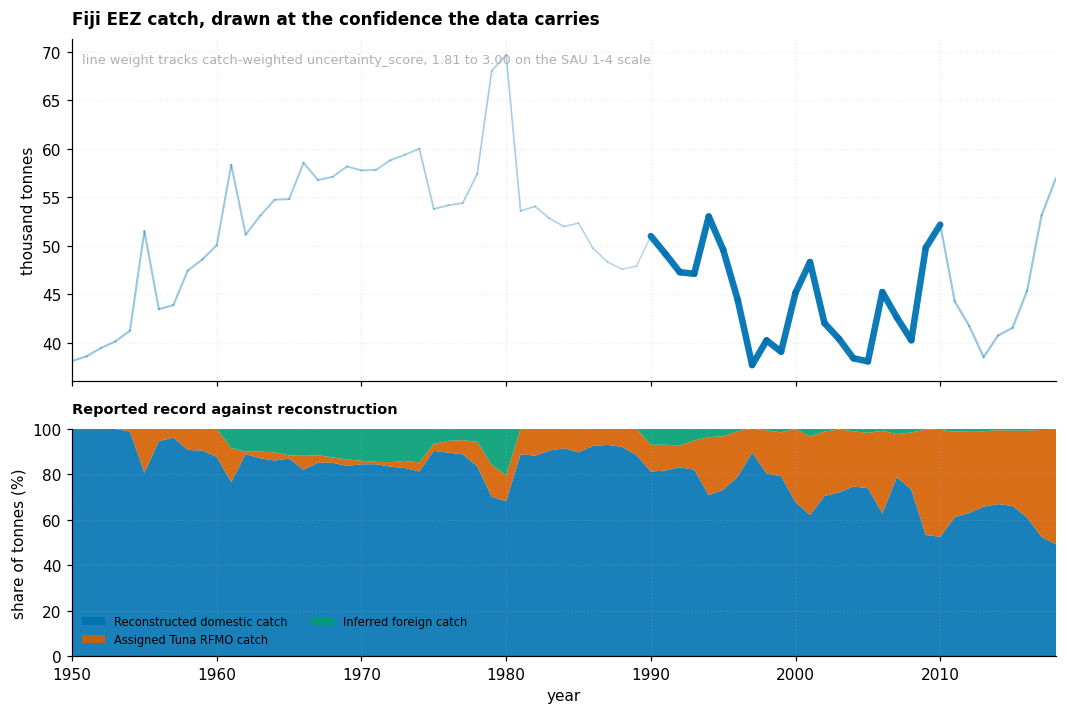

80% of Fiji EEZ tonnage is reconstructed estimate rather than reported record. Catch-weighted uncertainty_score averages 2.24 on the SAU 1-4 scale, moving from 1.99 in 1950 to 2.00 in 2018. Any forecast built on the early years inherits that uncertainty whether or not it declares it.


In [10]:
# Weight only over rows that actually carry a score, then realign to the full
# tonnage series - otherwise unscored rows silently drag the mean down.
tot_t = EEZ.groupby('year').tonnes.sum()
scored = EEZ.dropna(subset=['uncertainty_score'])
u = (scored.assign(w=scored.uncertainty_score * scored.tonnes)
     .groupby('year')[['w', 'tonnes']].sum())
u = u.reindex(tot_t.index)
u['score'] = (u.w / u.tonnes).ffill().bfill()

lay = EEZ.pivot_table(index='year', columns='data_layer',
                      values='tonnes', aggfunc='sum').fillna(0.0)
lshare = lay.div(lay.sum(axis=1), axis=0) * 100

fig, (ax, axl) = plt.subplots(2, 1, figsize=(9.8, 6.6), sharex=True,
                              gridspec_kw={'height_ratios': [3, 2]})
t = tot_t / 1e3
lo, hi = u.score.min(), u.score.max()
for i in range(len(t) - 1):
    a = (u.score.iloc[i] - lo) / (hi - lo + 1e-9)
    ax.plot(t.index[i:i + 2], t.iloc[i:i + 2], color=OI[0],
            lw=0.9 + 3.4 * a, alpha=.3 + .65 * a, solid_capstyle='round')
ax.set_ylabel('thousand tonnes')
ax.yaxis.set_major_formatter(K)
ax.set_title('Fiji EEZ catch, drawn at the confidence the data carries', loc='left')
ax.text(.01, .96, f'line weight tracks catch-weighted uncertainty_score, '
                  f'{lo:.2f} to {hi:.2f} on the SAU 1-4 scale',
        transform=ax.transAxes, fontsize=8.5, color=GREY, va='top')

o2 = list(lshare.mean().sort_values(ascending=False).index)
axl.stackplot(lshare.index, *[lshare[c] for c in o2], labels=[str(c) for c in o2],
              colors=OI[:len(o2)], alpha=.9)
axl.set_ylim(0, 100); axl.set_xlim(lshare.index.min(), lshare.index.max())
axl.set_ylabel('share of tonnes (%)'); axl.set_xlabel('year')
axl.legend(loc='lower left', fontsize=7.5, frameon=False, ncol=2)
axl.set_title('Reported record against reconstruction', loc='left', fontsize=9.5)
plt.tight_layout(); plt.show()

recon = [c for c in lay.columns if 'recon' in str(c).lower()]
rs = lshare[recon].sum(axis=1).mean() if recon else float('nan')
FINDINGS['8. Confidence'] = (
    f'{rs:.0f}% of Fiji EEZ tonnage is reconstructed estimate rather than reported '
    f'record. Catch-weighted uncertainty_score averages {u.score.mean():.2f} on the SAU '
    f'1-4 scale, moving from {u.score.iloc[0]:.2f} in {u.index.min()} to '
    f'{u.score.iloc[-1]:.2f} in {u.index.max()}. Any forecast built on the early years '
    f'inherits that uncertainty whether or not it declares it.')
print(FINDINGS['8. Confidence'])

## 10. Verification

One runnable check covering every derived quantity above. If a share stops
summing to 100, a rate escapes 0-100, or the Marimekko widths stop summing to 1,
this fails loudly rather than producing a plausible wrong chart.

In [11]:
def check():
    assert {'tonnes', 'landed_value', 'year'} <= set(GLOB.columns)
    assert (GLOB.tonnes >= 0).all(), 'negative tonnage in GLOBAL'
    assert (TAXA.tonnes >= 0).all(), 'negative tonnage in TAXA'
    assert abs(share.sum(axis=1) - 100).max() < 1e-6, 'end-use shares do not sum to 100'
    assert abs(lshare.sum(axis=1) - 100).max() < 1e-6, 'data-layer shares do not sum to 100'
    assert abs(bs.sum(axis=1) - 100).max() < 1e-6, 'size-band shares do not sum to 100'
    assert abs(cg.w.sum() - 1) < 1e-9, 'marimekko widths do not sum to 1'
    assert rate.between(0, 100).all(), 'yearly discard rate outside 0-100'
    assert gg.discard_rate.between(0, 100).all(), 'gear discard rate outside 0-100'
    assert d.early.between(0, 100).all(), 'early unreported share outside 0-100'
    assert d.late.between(0, 100).all(), 'late unreported share outside 0-100'
    assert rk.min().min() >= 1, 'ranks must start at 1'
    assert 0 < cov <= 100, 'size-band coverage outside 0-100'
    assert u.score.dropna().between(1, 4).all(), 'score off the SAU 1-4 scale'
    # Discard value must reconcile against the source table, not just the pivot.
    src = GLOB.loc[GLOB.catch_type.str.contains('disc', case=False, na=False),
                   'landed_value'].sum() / 1e9
    assert abs(src - dv.sum()) < 1e-6 * max(src, 1.0), 'discard value lost in the pivot'
    print('all checks passed')

check()

all checks passed


## 11. Findings

In [12]:
print('=' * 80)
for k, v in FINDINGS.items():
    print()
    print(k.upper())
    for line in textwrap.wrap(v, 78):
        print('  ' + line)
print()
print('=' * 80)


1. DISCARDS
  725 Mt discarded since 1950, carrying 1,062 bn USD of landed value that never
  reached a market. The discard rate peaked at 20.8% in 1955 and sat at 7.8% in
  2018. At the latest rate the fleet forgoes 12.6 bn USD a year - recoverable
  revenue that needs no additional fishing effort, only selectivity.

2. GEAR
  Across 29 material gears the median discards 4.5% and earns 1,466 USD/t.
  longline is the worst-quadrant workhorse: 13% discarded at only 1,466 USD/t
  across 160 Mt - the clearest candidate for gear substitution or quota
  pressure. purse seine shows the frontier is reachable: 3% discarded at 1,466
  USD/t.

3. END USE
  0.0 Mt went to fishmeal and oil in 2018, 0.0% of world catch, against a peak
  of 26.4% in 1968. That routing gives up about 0 USD per tonne against direct
  human consumption, roughly 0.0 bn USD a year of forgone gross value - and it
  is the margin case, not the ethics case, that moves a procurement team.

4. TRACEABILITY
  World unreported

### How these compose

Charts 1 and 2 are one recommendation in two parts: the discard ledger sizes the
prize, the gear quadrant names the lever. Charts 3 and 7 are the same margin
argument at different grains - end use and species group. Charts 4 and 8 are the
caveat layer and should be read before anyone quotes 1, 3 or 7 externally.

Charts 5 and 6 are the pair worth arguing about: tonnage rank says who is
winning, mean body size says what the winning costs. A fleet can climb chart 5
while pushing chart 6 down, which is exactly the failure mode a volume-only
dashboard cannot detect.